<a href="https://colab.research.google.com/github/kishor-cypto/projects/blob/main/Skin_Cancer_Detection_Using_a_Convolutional_Neural_Network_(CNN)_for_Binary_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import shutil
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

print("Libraries Imported")

Libraries Imported


In [4]:
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

print("Seeds Set")

Seeds Set


In [5]:
cancer_train = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Cancer/Training"

cancer_test = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Cancer/Testing"

non_train = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Non_Cancer/Training"

non_test = "/content/drive/MyDrive/skin cancer binary classification dataset/Skin_Data/Non_Cancer/Testing"

print(len(os.listdir(cancer_train)))
print(len(os.listdir(cancer_test)))
print(len(os.listdir(non_train)))
print(len(os.listdir(non_test)))

42
42
42
162


In [6]:
new_base = "/content/SkinCancer"

train_dir = os.path.join(new_base,"train")
test_dir = os.path.join(new_base,"test")

train_cancer = os.path.join(train_dir,"Cancer")
train_non = os.path.join(train_dir,"Non_Cancer")

test_cancer = os.path.join(test_dir,"Cancer")
test_non = os.path.join(test_dir,"Non_Cancer")

folders = [
    train_cancer,
    train_non,
    test_cancer,
    test_non
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

In [7]:
for img in os.listdir(cancer_train):
    shutil.copy(
        os.path.join(cancer_train,img),
        os.path.join(train_cancer,img)
    )

for img in os.listdir(non_train):
    shutil.copy(
        os.path.join(non_train,img),
        os.path.join(train_non,img)
    )

In [8]:
for img in os.listdir(cancer_test):
    shutil.copy(
        os.path.join(cancer_test,img),
        os.path.join(test_cancer,img)
    )

for img in os.listdir(non_test):
    shutil.copy(
        os.path.join(non_test,img),
        os.path.join(test_non,img)
    )

print("Dataset Prepared")

Dataset Prepared


In [9]:
IMG_SIZE = 128
BATCH_SIZE = 16

In [10]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)

validation_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2

)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [11]:
train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(IMG_SIZE,IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="binary",

    subset="training",

    shuffle=True

)

Found 68 images belonging to 2 classes.


In [12]:
validation_generator = validation_datagen.flow_from_directory(

    train_dir,

    target_size=(IMG_SIZE,IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="binary",

    subset="validation",

    shuffle=True

)

Found 16 images belonging to 2 classes.


In [13]:
test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=(IMG_SIZE,IMG_SIZE),

    batch_size=1,

    class_mode="binary",

    shuffle=False

)

Found 204 images belonging to 2 classes.


In [14]:
print(train_generator.class_indices)

class_names = list(train_generator.class_indices.keys())

print(class_names)

{'Cancer': 0, 'Non_Cancer': 1}
['Cancer', 'Non_Cancer']


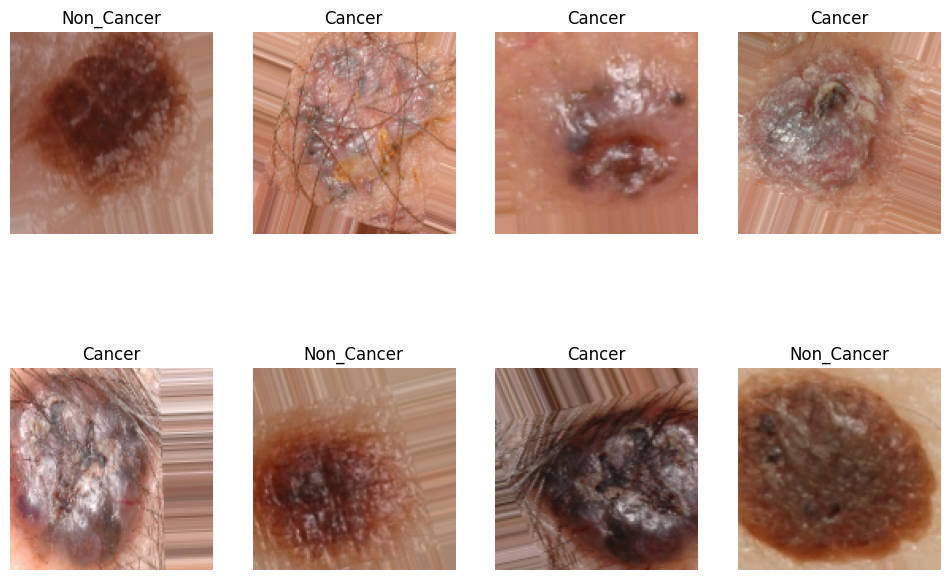

In [15]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i])

    plt.title(class_names[int(labels[i])])

    plt.axis("off")

plt.show()

In [17]:
# BUILD CNN MODEL

model = models.Sequential([


    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2,2),



    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2,2),



    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(2,2),



    layers.GlobalAveragePooling2D(),



    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),


    layers.Dense(
        1,
        activation='sigmoid'
    )

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']

)

print("Model Compiled")

Model Compiled


In [19]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True,

    verbose=1

)

In [21]:
checkpoint = ModelCheckpoint(

    "Best_Skin_Cancer_Model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    mode='max',

    verbose=1

)

In [22]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    min_lr=1e-7,

    verbose=1

)

In [23]:
EPOCHS = 20

history = model.fit(

    train_generator,

    epochs=EPOCHS,

    validation_data=validation_generator,

    callbacks=[

        early_stop,

        checkpoint,

        reduce_lr

    ]

)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4632 - loss: 0.9789
Epoch 1: val_accuracy improved from None to 0.50000, saving model to Best_Skin_Cancer_Model.keras

Epoch 1: finished saving model to Best_Skin_Cancer_Model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4265 - loss: 0.8720 - val_accuracy: 0.5000 - val_loss: 0.6930 - learning_rate: 1.0000e-04
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.6085 - loss: 0.6769
Epoch 2: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 652ms/step - accuracy: 0.5735 - loss: 0.6960 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accuracy: 0.6421 - loss: 0.6501
Epoch 3: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 873ms/step - accuracy: 0.6618 - loss: 0.6381 - val_accuracy: 0.5000 - val_loss: 0.6936 - learning_rate: 1.0000e-04
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy

In [24]:
model.save("SkinCancerCNN.keras")

print("Model Saved")

Model Saved


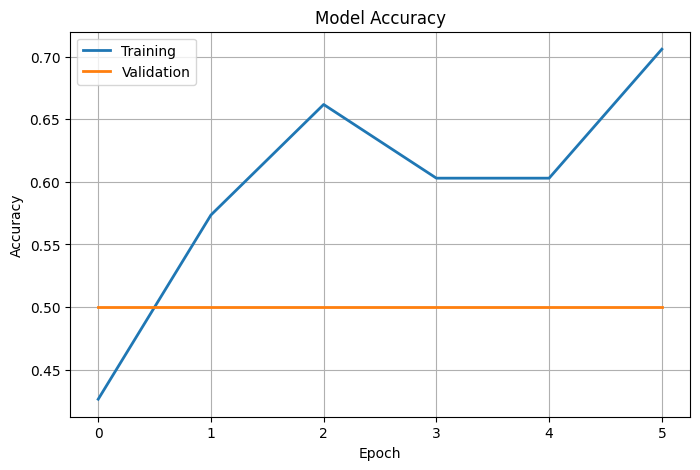

In [25]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history['accuracy'],

    linewidth=2

)

plt.plot(

    history.history['val_accuracy'],

    linewidth=2

)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(

    [

        "Training",

        "Validation"

    ]

)

plt.grid(True)

plt.show()

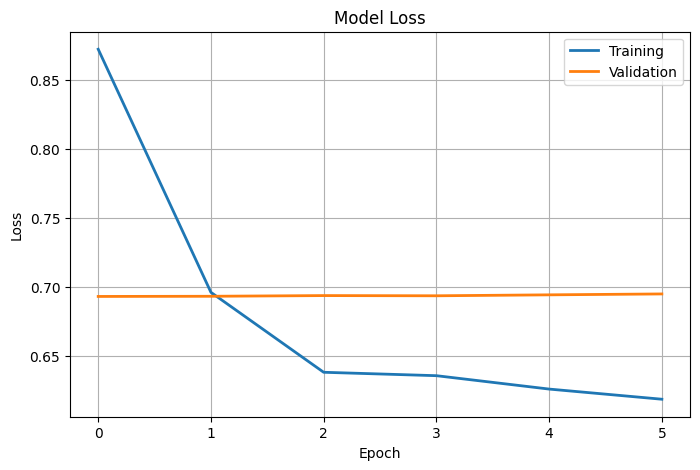

In [26]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history['loss'],

    linewidth=2

)

plt.plot(

    history.history['val_loss'],

    linewidth=2

)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(

    [

        "Training",

        "Validation"

    ]

)

plt.grid(True)

plt.show()

In [28]:
test_loss, test_accuracy = model.evaluate(test_generator)

print()

print("Test Accuracy : {:.2f}%".format(test_accuracy*100))

print("Test Loss :", test_loss)

204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7206 - loss: 0.6912

Test Accuracy : 72.06%
Test Loss : 0.6912257671356201


In [29]:
test_generator.reset()

pred_probs = model.predict(test_generator)

pred_probs = pred_probs.flatten()

pred_classes = (pred_probs > 0.5).astype(int)

true_classes = test_generator.classes

print(pred_classes[:10])

print(true_classes[:10])

204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
[1 1 1 0 1 1 0 1 1 1]
[0 0 0 0 0 0 0 0 0 0]


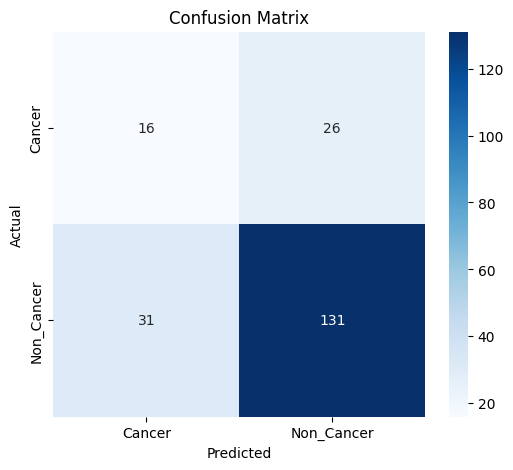

In [31]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cancer','Non_Cancer'],
    yticklabels=['Cancer','Non_Cancer']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [32]:
print(

    classification_report(

        true_classes,

        pred_classes,

        target_names=[
            "Cancer",
            "Non_Cancer"
        ]

    )

)

              precision    recall  f1-score   support

      Cancer       0.34      0.38      0.36        42
  Non_Cancer       0.83      0.81      0.82       162

    accuracy                           0.72       204
   macro avg       0.59      0.59      0.59       204
weighted avg       0.73      0.72      0.73       204



In [33]:
precision = precision_score(
    true_classes,
    pred_classes
)

print("Precision :", precision)

Precision : 0.8343949044585988


In [34]:
f1 = f1_score(
    true_classes,
    pred_classes
)

print("F1 Score :", f1)

F1 Score : 0.8213166144200627


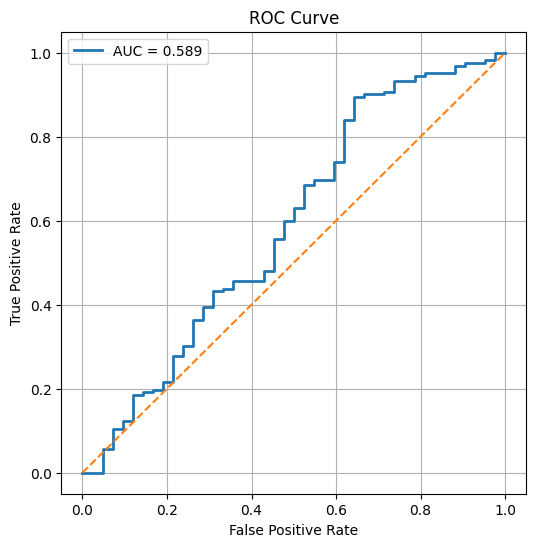

In [35]:
fpr, tpr, thresholds = roc_curve(

    true_classes,

    pred_probs

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label='AUC = %0.3f'%roc_auc

)

plt.plot(

    [0,1],

    [0,1],

    linestyle='--'

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [36]:
print()

print("AUC Score :", roc_auc)


AUC Score : 0.5892122281011171


In [39]:
print()

print("========== RESULTS ==========")

print()

print("Accuracy : {:.4f}".format(test_accuracy))

print()

print("Precision : {:.4f}".format(precision))

print()

print("F1 Score : {:.4f}".format(f1))

print()

print("AUC Score : {:.4f}".format(roc_auc))

print()

print("=============================")


========== RESULTS ==========

Accuracy : 0.7206

Precision : 0.8344

F1 Score : 0.8213

AUC Score : 0.5892



In [40]:
from PIL import Image
import numpy as np

def load_and_preprocess_image(image_path):

    img = Image.open(image_path)

    img = img.convert("RGB")

    img = img.resize((IMG_SIZE, IMG_SIZE))

    img_array = np.array(img)

    img_array = img_array.astype("float32") / 255.0

    img_array = np.expand_dims(img_array, axis=0)

    return img_array

In [41]:
def predict_image(model, image_path):

    image = load_and_preprocess_image(image_path)

    probability = model.predict(image)[0][0]

    if probability < 0.5:
        predicted_class = "Cancer"
        confidence = (1 - probability) * 100

    else:
        predicted_class = "Non_Cancer"
        confidence = probability * 100

    print()

    print("Prediction :", predicted_class)

    print("Confidence : {:.2f}%".format(confidence))

    print()

    return predicted_class

In [42]:
def show_image(image_path):

    img = Image.open(image_path)

    plt.figure(figsize=(5,5))

    plt.imshow(img)

    plt.axis("off")

    plt.show()

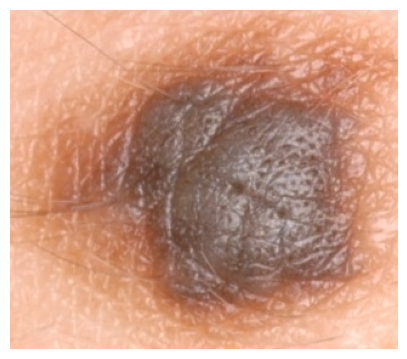

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

Prediction : Non_Cancer
Confidence : 50.35%



'Non_Cancer'

In [44]:
image_path = "/content/SkinCancer/test/Non_Cancer/1045-2.JPG"

show_image(image_path)

predict_image(model,image_path)

In [45]:
from tensorflow.keras.models import load_model

model = load_model("SkinCancerCNN.keras")

print("Model Loaded")

Model Loaded
